In [1]:
import glob
import os
import re
import pickle
import pandas as pd
import numpy as np
import os
import glob
import re
import time
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

from utils import ml_pipeline as ml
from utils import plotting

/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Sensitivity analysis on English-only and Spanish-only data from the pilot dataset (N=22)

In [125]:
liwc_proba = pd.read_pickle('./evaluation-test-UPD/liwc22-size100-probs.pkl')
liwc_proba = liwc_proba['Random Forest']

df_liwc_train = pd.read_pickle('./FEATURES/dfs/liwc22-size100.pkl')

df_liwc_test = pd.read_pickle('./FEATURES/test-features/dfs/liwc22-size100.pkl')
y_test = df_liwc_test['label']

df_hri = pd.read_pickle("./external/HRI/liwc/newLIWC22/df_liwc_all-size100.pkl")

groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)

In [12]:
groups

,adressfname,gender,dx,age,mmse,pid,mmse_split,age_split
0,adrso004,female,Control,74,30.0,15,cn,70-80
1,adrso006,female,Control,65,28.0,40,cn,60-69
2,adrso009,female,Control,68,29.0,26,cn,60-69
3,adrso011,female,Control,71,30.0,67,cn,70-80
4,adrso013,female,Control,70,29.0,58,cn,70-80
...,...,...,...,...,...,...,...,...
66,adrso303,male,Control,66,29.0,55,cn,60-69
67,adrso304,male,Control,70,30.0,68,cn,70-80
68,adrso313,female,Control,63,28.0,31,cn,60-69
69,adrso314,female,Control,61,29.0,5,cn,60-69


In [36]:
df_liwc_train

,pid,label,data
0,267,0,"[81, 58.92, 54.78, 83.36, 20.23, 4.26, 8.64, 9..."
1,273,0,"[110, 80.0, 71.57, 20.79, 47.86, 10.0, 13.64, ..."
2,298,0,"[92, 84.34, 93.93, 44.75, 35.66, 7.08, 14.13, ..."
3,307,0,"[83, 56.34, 74.41, 13.52, 76.34, 7.55, 7.23, 7..."
4,312,0,"[128, 64.33, 75.49, 48.9, 30.91, 5.82, 11.72, ..."
...,...,...,...
161,055,1,"[132, 49.68, 74.59, 55.91, 30.55, 6.6, 8.33, 9..."
162,109,1,"[154, 60.69, 92.08, 17.57, 13.3, 7.7, 13.64, 9..."
163,134,1,"[59, 94.96, 96.3, 30.14, 73.26, 6.56, 16.95, 8..."
164,054,1,"[114, 7.07, 40.06, 64.56, 46.76, 6.33, 8.77, 9..."


In [126]:
results=[]
# Iterate over the probabilities and runs
for run, probs in enumerate(liwc_proba):
    # Create a DataFrame for each run
    run_df = pd.DataFrame({
        'pid': df_liwc_test['pid'],
        'prob': probs.round(2),
        'y_true': df_liwc_test['label'],
        'run': run
    })
    
    # Append the DataFrame to the results list
    results.append(run_df)

# Concatenate all the results into a single DataFrame
df_all = pd.concat(results).reset_index(drop=True)
df_all.head()

,pid,prob,y_true,run
0,58,0.24,0,0
1,64,0.52,1,0
2,70,0.60,1,0
3,71,0.83,1,0
4,65,0.25,0,0


In [35]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pid     710 non-null    object 
 1   prob    710 non-null    float64
 2   y_true  710 non-null    int64  
 3   run     710 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 22.3+ KB


In [127]:
merged_df_all = df_all.merge(groups, left_on='pid', right_on='pid', how='left')
merged_df_all['gender'] = merged_df_all['gender'].map({'female': 'F', 'male': 'M'}).fillna('NA')
s = ['pid', 'mmse', 'prob', 'y_true', 'mmse_split', 'age_split', 'run']
merged_df_all = merged_df_all[s]
# we dont know the value of MMSE but know its CN group
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse_split'] = 'cn'
merged_df_all.loc[merged_df_all['pid'] == '54', 'mmse'] = 28
# y_test
y_test_boots = merged_df_all.y_true
merged_df_all.head()

,pid,mmse,prob,y_true,mmse_split,age_split,run
0,58,29.0,0.24,0,cn,70-80,0
1,64,24.0,0.52,1,ad-mil,60-69,0
2,70,18.0,0.60,1,ad-mod,50-59,0
3,71,24.0,0.83,1,ad-mil,70-80,0
4,65,30.0,0.25,0,cn,50-59,0


In [5]:
df_liwc_test

,pid,label,data
0,58,0,"[57, 47.02, 94.48, 1.0, 5.65, 8.14, 14.04, 89...."
1,64,1,"[57, 62.72, 70.59, 14.46, 74.93, 5.7, 15.79, 9..."
2,70,1,"[62, 95.94, 97.31, 25.64, 6.37, 4.43, 6.45, 95..."
3,71,1,"[156, 1.0, 99.0, 1.31, 49.66, 19.5, 13.46, 97...."
4,65,0,"[107, 88.19, 94.26, 10.52, 48.73, 15.29, 12.15..."
...,...,...,...
66,68,0,"[113, 86.9, 79.24, 53.37, 20.23, 12.56, 15.93,..."
67,69,0,"[111, 99.0, 93.46, 98.8, 32.75, 6.53, 15.32, 8..."
68,55,0,"[248, 74.04, 86.1, 6.29, 25.43, 9.92, 15.32, 8..."
69,41,1,"[49, 97.86, 74.89, 66.12, 82.06, 12.25, 14.29,..."


In [6]:
groups

,adressfname,gender,dx,age,mmse,pid,mmse_split,age_split
0,adrso004,female,Control,74,30.0,15,cn,70-80
1,adrso006,female,Control,65,28.0,40,cn,60-69
2,adrso009,female,Control,68,29.0,26,cn,60-69
3,adrso011,female,Control,71,30.0,67,cn,70-80
4,adrso013,female,Control,70,29.0,58,cn,70-80
...,...,...,...,...,...,...,...,...
66,adrso303,male,Control,66,29.0,55,cn,60-69
67,adrso304,male,Control,70,30.0,68,cn,70-80
68,adrso313,female,Control,63,28.0,31,cn,60-69
69,adrso314,female,Control,61,29.0,5,cn,60-69


In [7]:
df_liwc_train

,pid,label,data
0,267,0,"[81, 58.92, 54.78, 83.36, 20.23, 4.26, 8.64, 9..."
1,273,0,"[110, 80.0, 71.57, 20.79, 47.86, 10.0, 13.64, ..."
2,298,0,"[92, 84.34, 93.93, 44.75, 35.66, 7.08, 14.13, ..."
3,307,0,"[83, 56.34, 74.41, 13.52, 76.34, 7.55, 7.23, 7..."
4,312,0,"[128, 64.33, 75.49, 48.9, 30.91, 5.82, 11.72, ..."
...,...,...,...
161,055,1,"[132, 49.68, 74.59, 55.91, 30.55, 6.6, 8.33, 9..."
162,109,1,"[154, 60.69, 92.08, 17.57, 13.3, 7.7, 13.64, 9..."
163,134,1,"[59, 94.96, 96.3, 30.14, 73.26, 6.56, 16.95, 8..."
164,054,1,"[114, 7.07, 40.06, 64.56, 46.76, 6.33, 8.77, 9..."


In [8]:
df_liwc_train.data[0].size

100

In [9]:
liwc_proba[0]

array([0.24378571, 0.5242619 , 0.60224603, 0.83431746, 0.24952381,
       0.34054762, 0.5516746 , 0.16938095, 0.54938095, 0.71452381,
       0.43909524, 0.44961111, 0.59985714, 0.19633333, 0.65466667,
       0.83136508, 0.55935714, 0.25355556, 0.24871429, 0.40209524,
       0.17602381, 0.84638095, 0.5132381 , 0.85795238, 0.69538095,
       0.58938095, 0.39034921, 0.68904762, 0.38628571, 0.54380952,
       0.77684921, 0.30096825, 0.61783333, 0.42660317, 0.48219048,
       0.6377619 , 0.30633333, 0.30989683, 0.3994127 , 0.35953968,
       0.53088889, 0.5074127 , 0.33202381, 0.89990476, 0.27163492,
       0.12519048, 0.36547619, 0.393     , 0.52159524, 0.35722222,
       0.70088889, 0.553     , 0.186     , 0.36026984, 0.80166667,
       0.27247619, 0.29590476, 0.829     , 0.44177778, 0.70854762,
       0.45446032, 0.32738095, 0.47414286, 0.40652381, 0.38407937,
       0.11785714, 0.30519048, 0.67712698, 0.1588254 , 0.49387302,
       0.85557143])

In [10]:
liwc_proba

[array([0.24378571, 0.5242619 , 0.60224603, 0.83431746, 0.24952381,
        0.34054762, 0.5516746 , 0.16938095, 0.54938095, 0.71452381,
        0.43909524, 0.44961111, 0.59985714, 0.19633333, 0.65466667,
        0.83136508, 0.55935714, 0.25355556, 0.24871429, 0.40209524,
        0.17602381, 0.84638095, 0.5132381 , 0.85795238, 0.69538095,
        0.58938095, 0.39034921, 0.68904762, 0.38628571, 0.54380952,
        0.77684921, 0.30096825, 0.61783333, 0.42660317, 0.48219048,
        0.6377619 , 0.30633333, 0.30989683, 0.3994127 , 0.35953968,
        0.53088889, 0.5074127 , 0.33202381, 0.89990476, 0.27163492,
        0.12519048, 0.36547619, 0.393     , 0.52159524, 0.35722222,
        0.70088889, 0.553     , 0.186     , 0.36026984, 0.80166667,
        0.27247619, 0.29590476, 0.829     , 0.44177778, 0.70854762,
        0.45446032, 0.32738095, 0.47414286, 0.40652381, 0.38407937,
        0.11785714, 0.30519048, 0.67712698, 0.1588254 , 0.49387302,
        0.85557143]),
 array([0.39078571, 0.79  

In [11]:
len(liwc_proba[0])

71

In [12]:
df_hri

,pid,data,age,gender,mmse,language,mmse_split,label
0,P13,"[111, 23.42, 66.53, 87.0, 20.23, 12.33, 4.5, 9...",93,M,23,English,ad-mil,1
1,P07,"[52, 1.84, 1.0, 99.0, 79.29, 10.4, 3.85, 100.0...",95,M,15,English,ad-mod,1
2,P06,"[74, 99.0, 83.39, 3.49, 20.23, 12.33, 14.86, 8...",68,M,25,English,ad-mil,1
3,P12,"[57, 41.78, 50.51, 45.82, 20.23, 5.7, 15.79, 9...",75,F,25,English,ad-mil,1
4,P04,"[106, 62.77, 62.44, 48.58, 10.8, 15.14, 13.21,...",81,M,29,English,cn,0
5,P10,"[73, 98.88, 83.81, 28.97, 20.23, 10.43, 13.7, ...",74,F,26,English,ad-mil,1
6,P05,"[267, 24.96, 90.78, 2.33, 3.64, 10.68, 14.23, ...",84,F,23,English,ad-mil,1
7,P15,"[118, 94.24, 30.62, 47.65, 11.57, 4.72, 11.02,...",80,F,28,English,cn,0
8,P14,"[36, 58.02, 84.23, 39.59, 20.23, 7.2, 8.33, 97...",67,M,18,English,ad-mod,1
9,P16,"[48, 94.18, 40.06, 39.59, 20.23, 16.0, 12.5, 8...",74,F,23,English,ad-mil,1


In [13]:
df_hri.data[0].size

100

Test set (N=71)

In [132]:
# TRAIN
X = df_liwc_train['data']
y = df_liwc_train['label']
X_train_2d = np.stack(X.values)
# Normalization
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_2d)

# TEST
X_test = df_liwc_test['data']
y_test = df_liwc_test['label']
X_test_2d = np.stack(X_test.values)
# Transform test set with scaler object already fit on training data
X_scaled_test = scaler.transform(X_test_2d)
best_hyperparams = ml.load_best_params_UPD(feature_set = 'w-liwc-size100') ### ENSURE CORRECT FEATURE SET
best_hyperparams = {'Random Forest': best_hyperparams['Random Forest']}

evaluation_bootstrap, probs = ml.fit_and_evaluate_bootstrap_(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(evaluation_bootstrap)
df = evaluation_bootstrap_df.round(3)
df[df.columns[1:]] = df[df.columns[1:]] * 100
results_dict = {}
for model_name in df.Model:
    print(model_name)
    results = ml.extract_results_classif_test(df[df.Model == model_name])
    results_dict[model_name] = results
results_dict

./hyperparam-tuning-UPD/w-liwc-size100/10fcv_lr.pkl
./hyperparam-tuning-UPD/w-liwc-size100/10fcv_svm.pkl
./hyperparam-tuning-UPD/w-liwc-size100/10fcv_rf.pkl
./hyperparam-tuning-UPD/w-liwc-size100/10fcv_nn.pkl
./hyperparam-tuning-UPD/w-liwc-size100/10fcv_xgboost.pkl
Random Forest


{'Random Forest': ('69.1 (64.4 - 73.8)',
  '82.8 (77.8 - 87.8)',
  '85.2 (82.3 - 88.1)',
  '76.1 (73.2 - 78.9)')}

In [ ]:
# TRAIN
X = df_liwc_train['data']
y = df_liwc_train['label']
X_train_2d = np.stack(X.values)
# Normalization
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_2d)

# TEST
X_test = df_liwc_test['data']
y_test = df_liwc_test['label']
X_test_2d = np.stack(X_test.values)
# Transform test set with scaler object already fit on training data
X_scaled_test = scaler.transform(X_test_2d)
best_hyperparams = ml.load_best_params_UPD(feature_set = 'w-liwc22')
best_hyperparams = {'Random Forest': best_hyperparams['Random Forest']}

evaluation_bootstrap, probs = ml.fit_and_evaluate_bootstrap_(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(evaluation_bootstrap)
df = evaluation_bootstrap_df.round(3)
df[df.columns[1:]] = df[df.columns[1:]] * 100
results_dict = {}
for model_name in df.Model:
    print(model_name)
    results = ml.extract_results_classif_test(df[df.Model == model_name])
    results_dict[model_name] = results
results_dict

./hyperparam-tuning-UPD/w-liwc22/10fcv_lr.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_svm.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_rf.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_nn.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_xgboost.pkl


/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:51:56] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


Random Forest


{'Random Forest': ('70.3 (66.9 - 73.7)',
  '82.2 (78.3 - 86.1)',
  '86.4 (84.6 - 88.3)',
  '76.3 (74.6 - 78.0)')}

In [129]:
# TRAIN
X = df_liwc_train['data']
y = df_liwc_train['label']
X_train_2d = np.stack(X.values)
# Normalization
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_2d)

# TEST
X_test = df_hri['data']
y_test = df_hri['label']
X_test_2d = np.stack(X_test.values)
# Transform test set with scaler object already fit on training data
X_scaled_test = scaler.transform(X_test_2d)
best_hyperparams = ml.load_best_params_UPD(feature_set = 'w-liwc-size100')
best_hyperparams = {'Random Forest': best_hyperparams['Random Forest']}
best_hyperparams

./hyperparam-tuning-UPD/w-liwc-size100/10fcv_lr.pkl
./hyperparam-tuning-UPD/w-liwc-size100/10fcv_svm.pkl
./hyperparam-tuning-UPD/w-liwc-size100/10fcv_rf.pkl
./hyperparam-tuning-UPD/w-liwc-size100/10fcv_nn.pkl
./hyperparam-tuning-UPD/w-liwc-size100/10fcv_xgboost.pkl


{'Random Forest': RandomForestClassifier(max_depth=16, min_samples_leaf=3, min_samples_split=4,
                        n_estimators=50, random_state=42)}

In [16]:
y_test

0     1
1     1
2     1
3     1
4     0
5     1
6     1
7     0
8     1
9     1
10    0
11    0
12    1
13    1
14    0
15    1
16    0
17    1
18    1
19    0
20    0
21    1
Name: label, dtype: int64

In [130]:
### with feature_set = 'w-liwc-size100'

evaluation_bootstrap, probs = ml.fit_and_evaluate_bootstrap_(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(evaluation_bootstrap)
df = evaluation_bootstrap_df.round(3)
df[df.columns[1:]] = df[df.columns[1:]] * 100
results_dict = {}
for model_name in df.Model:
    print(model_name)
    results = ml.extract_results_classif_test(df[df.Model == model_name])
    results_dict[model_name] = results
results_dict

Random Forest


{'Random Forest': ('68.6 (60.9 - 76.3)',
  '48.8 (39.9 - 57.6)',
  '65.1 (61.1 - 69.2)',
  '61.4 (55.8 - 66.9)')}

In [ ]:
### feature_set = 'w-liwc22'

evaluation_bootstrap, probs = ml.fit_and_evaluate_bootstrap_(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(evaluation_bootstrap)
df = evaluation_bootstrap_df.round(3)
df[df.columns[1:]] = df[df.columns[1:]] * 100
results_dict = {}
for model_name in df.Model:
    print(model_name)
    results = ml.extract_results_classif_test(df[df.Model == model_name])
    results_dict[model_name] = results
results_dict

Random Forest


{'Random Forest': ('70.0 (60.7 - 79.3)',
  '50.0 (39.7 - 60.3)',
  '64.6 (59.6 - 69.7)',
  '62.7 (59.0 - 66.4)')}

In [18]:
probs

{'Random Forest': [array([0.80743684, 0.73856311, 0.61093374, 0.49003479, 0.51991155,
         0.56243546, 0.59489574, 0.46479256, 0.72549721, 0.51570037,
         0.64018803, 0.54822488, 0.63162943, 0.41263279, 0.62922443,
         0.51928711, 0.56428529, 0.55676984, 0.33528692, 0.36882027,
         0.44663075, 0.54258463]),
  array([0.82218315, 0.75271088, 0.55367395, 0.47097008, 0.34176773,
         0.60659452, 0.61449285, 0.42018138, 0.67611565, 0.57834014,
         0.5802034 , 0.54678162, 0.64486682, 0.46275033, 0.68554683,
         0.53119496, 0.6063905 , 0.57826355, 0.29502885, 0.36056387,
         0.51690687, 0.61960019]),
  array([0.81796883, 0.73295409, 0.50452818, 0.57216436, 0.51703453,
         0.52664573, 0.6554201 , 0.33613212, 0.61270392, 0.49554655,
         0.43494318, 0.45329829, 0.64221058, 0.64926764, 0.66217628,
         0.44750608, 0.4933862 , 0.54383566, 0.28191825, 0.32796514,
         0.52327392, 0.55261695]),
  array([0.79167687, 0.73479932, 0.5773261 , 0.491

In [19]:
len(probs['Random Forest'])

10

In [20]:
len(probs['Random Forest'][0])

22

#### Separate predictions

In [21]:
df_hri_English = df_hri[df_hri['language'] == 'English']
df_hri_English

,pid,data,age,gender,mmse,language,mmse_split,label
0,P13,"[111, 23.42, 66.53, 87.0, 20.23, 12.33, 4.5, 9...",93,M,23,English,ad-mil,1
1,P07,"[52, 1.84, 1.0, 99.0, 79.29, 10.4, 3.85, 100.0...",95,M,15,English,ad-mod,1
2,P06,"[74, 99.0, 83.39, 3.49, 20.23, 12.33, 14.86, 8...",68,M,25,English,ad-mil,1
3,P12,"[57, 41.78, 50.51, 45.82, 20.23, 5.7, 15.79, 9...",75,F,25,English,ad-mil,1
4,P04,"[106, 62.77, 62.44, 48.58, 10.8, 15.14, 13.21,...",81,M,29,English,cn,0
5,P10,"[73, 98.88, 83.81, 28.97, 20.23, 10.43, 13.7, ...",74,F,26,English,ad-mil,1
6,P05,"[267, 24.96, 90.78, 2.33, 3.64, 10.68, 14.23, ...",84,F,23,English,ad-mil,1
7,P15,"[118, 94.24, 30.62, 47.65, 11.57, 4.72, 11.02,...",80,F,28,English,cn,0
8,P14,"[36, 58.02, 84.23, 39.59, 20.23, 7.2, 8.33, 97...",67,M,18,English,ad-mod,1
9,P16,"[48, 94.18, 40.06, 39.59, 20.23, 16.0, 12.5, 8...",74,F,23,English,ad-mil,1


In [22]:
df_hri_Spanish = df_hri[df_hri['language'] == 'Spanish']
df_hri_Spanish

,pid,data,age,gender,mmse,language,mmse_split,label
14,P17,"[114, 41.78, 92.86, 6.22, 74.93, 5.18, 13.16, ...",70,F,29,Spanish,cn,0
15,P19,"[72, 99.0, 56.63, 2.15, 20.23, 6.55, 11.11, 84...",71,F,25,Spanish,ad-mil,1
16,P25,"[65, 39.7, 75.04, 63.35, 20.23, 7.22, 10.77, 9...",69,F,30,Spanish,cn,0
17,P24,"[34, 97.25, 93.56, 46.57, 66.58, 3.4, 2.94, 88...",71,F,21,Spanish,ad-mil,1
18,P20,"[87, 81.78, 60.57, 21.61, 36.68, 4.83, 14.94, ...",78,F,22,Spanish,ad-mil,1
19,P21,"[60, 59.67, 84.23, 1.0, 45.29, 6.0, 13.33, 88....",66,F,30,Spanish,cn,0
20,P23,"[76, 14.93, 87.2, 1.0, 20.23, 8.44, 13.16, 92....",79,F,28,Spanish,cn,0
21,P22,"[32, 95.8, 98.18, 54.55, 69.4, 5.33, 6.25, 96....",75,M,24,Spanish,ad-mil,1


In [23]:
len(df_hri_Spanish), len(df_hri_English)

(8, 14)

English new predictions

In [24]:
# TRAIN
X = df_liwc_train['data']
y = df_liwc_train['label']
X_train_2d = np.stack(X.values)
# Normalization
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_2d)

# TEST ENGLISH
X_test = df_hri_English['data']
y_test = df_hri_English['label']
X_test_2d = np.stack(X_test.values)
# Transform test set with scaler object already fit on training data
X_scaled_test = scaler.transform(X_test_2d)
best_hyperparams = ml.load_best_params_UPD(feature_set = 'w-liwc22')
best_hyperparams = {'Random Forest': best_hyperparams['Random Forest']}

evaluation_bootstrap, probs = ml.fit_and_evaluate_bootstrap_(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(evaluation_bootstrap)
df = evaluation_bootstrap_df.round(3)
df[df.columns[1:]] = df[df.columns[1:]] * 100
results_dict = {}
for model_name in df.Model:
    print(model_name)
    results = ml.extract_results_classif_test(df[df.Model == model_name])
    results_dict[model_name] = results
results_dict

./hyperparam-tuning-UPD/w-liwc22/10fcv_lr.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_svm.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_rf.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_nn.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_xgboost.pkl
Random Forest


{'Random Forest': ('71.0 (61.8 - 80.2)',
  '60.0 (42.7 - 77.3)',
  '77.0 (70.8 - 83.2)',
  '67.9 (61.8 - 73.9)')}

Spanish new predictions

In [25]:
# TRAIN
X = df_liwc_train['data']
y = df_liwc_train['label']
X_train_2d = np.stack(X.values)
# Normalization
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_2d)

# TEST ENGLISH
X_test = df_hri_Spanish['data']
y_test = df_hri_Spanish['label']
X_test_2d = np.stack(X_test.values)
# Transform test set with scaler object already fit on training data
X_scaled_test = scaler.transform(X_test_2d)
best_hyperparams = ml.load_best_params_UPD(feature_set = 'w-liwc22')
best_hyperparams = {'Random Forest': best_hyperparams['Random Forest']}

evaluation_bootstrap, probs = ml.fit_and_evaluate_bootstrap_(best_hyperparams, X_scaled_train, y, X_scaled_test, y_test)
evaluation_bootstrap_df = pd.DataFrame(evaluation_bootstrap)
df = evaluation_bootstrap_df.round(3)
df[df.columns[1:]] = df[df.columns[1:]] * 100
results_dict = {}
for model_name in df.Model:
    print(model_name)
    results = ml.extract_results_classif_test(df[df.Model == model_name])
    results_dict[model_name] = results
results_dict

./hyperparam-tuning-UPD/w-liwc22/10fcv_lr.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_svm.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_rf.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_nn.pkl
./hyperparam-tuning-UPD/w-liwc22/10fcv_xgboost.pkl
Random Forest


{'Random Forest': ('67.5 (52.8 - 82.2)',
  '40.0 (30.8 - 49.2)',
  '45.6 (36.7 - 54.6)',
  '53.8 (47.7 - 59.8)')}

Could this be due to different MMSE distributions in each language group?

In [26]:
df_hri_Spanish.columns

Index(['pid', 'data', 'age', 'gender', 'mmse', 'language', 'mmse_split',
       'label'],
      dtype='object')

In [27]:
print('Spanish')
print(df_hri_Spanish.mmse_split.value_counts())

print('English')
print(df_hri_English.mmse_split.value_counts())

Spanish
mmse_split
cn        4
ad-mil    4
Name: count, dtype: int64
English
mmse_split
ad-mil    8
cn        4
ad-mod    2
Name: count, dtype: int64


In [28]:
df_hri_Spanish.mmse.mean(), df_hri_English.mmse.mean()  

(26.125, 24.214285714285715)

### WER per cognitive group

- further analysis on how ASR errors impact model performance would be beneficial.
- Is there a relationship between amount of ASR error and prediction of ADRD? 
- Exploring ASR robustness across different cognitive states could further strengthen the analysis

In [2]:
groups = pd.read_csv('mapping.csv')
groups['mapping'] = groups['mapping'].str.replace('adrsdt', '')
groups.rename(columns={'mapping': 'pid'}, inplace=True)
# we dont know the value of MMSE but know its CN group
groups.loc[groups['pid'] == '54', 'mmse_split'] = 'cn'
groups.loc[groups['pid'] == '54', 'mmse'] = 28
groups

,adressfname,gender,dx,age,mmse,pid,mmse_split,age_split
0,adrso004,female,Control,74,30.0,15,cn,70-80
1,adrso006,female,Control,65,28.0,40,cn,60-69
2,adrso009,female,Control,68,29.0,26,cn,60-69
3,adrso011,female,Control,71,30.0,67,cn,70-80
4,adrso013,female,Control,70,29.0,58,cn,70-80
...,...,...,...,...,...,...,...,...
66,adrso303,male,Control,66,29.0,55,cn,60-69
67,adrso304,male,Control,70,30.0,68,cn,70-80
68,adrso313,female,Control,63,28.0,31,cn,60-69
69,adrso314,female,Control,61,29.0,5,cn,60-69


In [30]:
groups[groups.pid == '54']

,adressfname,gender,dx,age,mmse,pid,mmse_split,age_split
51,adrso256,male,Control,74,28.0,54,cn,70-80


In [2]:
asr_folder_path = "./FEATURES/stt_whisper/WER/asr"
ref_folder_path = "./FEATURES/stt_whisper/WER/manual"

asr_files = sorted(os.listdir(asr_folder_path))
ref_files = sorted(os.listdir(ref_folder_path))
ref_files

['.DS_Store',
 'stt_adrso002.txt',
 'stt_adrso003.txt',
 'stt_adrso005.txt',
 'stt_adrso007.txt',
 'stt_adrso008.txt',
 'stt_adrso010.txt',
 'stt_adrso012.txt',
 'stt_adrso014.txt',
 'stt_adrso015.txt',
 'stt_adrso016.txt',
 'stt_adrso017.txt',
 'stt_adrso018.txt',
 'stt_adrso019.txt',
 'stt_adrso021.txt',
 'stt_adrso022.txt',
 'stt_adrso023.txt',
 'stt_adrso024.txt',
 'stt_adrso025.txt',
 'stt_adrso027.txt',
 'stt_adrso028.txt',
 'stt_adrso031.txt',
 'stt_adrso032.txt',
 'stt_adrso033.txt',
 'stt_adrso035.txt',
 'stt_adrso036.txt',
 'stt_adrso039.txt',
 'stt_adrso043.txt',
 'stt_adrso045.txt',
 'stt_adrso046.txt',
 'stt_adrso047.txt',
 'stt_adrso049.txt',
 'stt_adrso053.txt',
 'stt_adrso054.txt',
 'stt_adrso055.txt',
 'stt_adrso056.txt',
 'stt_adrso059.txt',
 'stt_adrso060.txt',
 'stt_adrso063.txt',
 'stt_adrso068.txt',
 'stt_adrso070.txt',
 'stt_adrso071.txt',
 'stt_adrso072.txt',
 'stt_adrso074.txt',
 'stt_adrso075.txt',
 'stt_adrso077.txt',
 'stt_adrso078.txt',
 'stt_adrso089.txt',

In [3]:
# Extract substrings from the list of strings
asr_files=asr_files[1:]
ref_files = ref_files[1:]
asr_files = [re.search(r'_(.*?)\.', file).group(1) for file in asr_files]
asr_files[:3]

['adrso002', 'adrso003', 'adrso005']

In [ ]:
len(asr_files), len(ref_files)

(106, 106)

In [8]:
# Read the CSV file
df = pd.read_csv('./dx-mmse.csv')

# Select only the specified columns
selected_columns = ['age', 'gender', 'mmse', 'dx', 'adressfname', 'test']
df = df[selected_columns]

df.loc[df['mmse'] < 10, 'mmse_split'] = 'ad-sev'
df.loc[(df['mmse'] >= 10) & (df['mmse'] <= 20), 'mmse_split'] = 'ad-mod'
df.loc[(df['mmse'] >= 21) & (df['mmse'] <= 26), 'mmse_split'] = 'ad-mil'
df.loc[df['mmse'] > 26, 'mmse_split'] = 'cn'

df.head()

,age,gender,mmse,dx,adressfname,test,mmse_split
0,70,female,26.0,Control,adrso002,False,ad-mil
1,72,female,30.0,Control,adrso003,False,cn
2,74,female,30.0,Control,adrso004,True,cn
3,67,female,27.0,Control,adrso005,False,cn
4,65,female,28.0,Control,adrso006,True,cn


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          237 non-null    int64  
 1   gender       237 non-null    object 
 2   mmse         236 non-null    float64
 3   dx           237 non-null    object 
 4   adressfname  237 non-null    object 
 5   test         237 non-null    bool   
 6   mmse_split   236 non-null    object 
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 11.5+ KB


In [15]:
df.mmse_split.value_counts()

mmse_split
cn        114
ad-mod     83
ad-mil     33
ad-sev      6
Name: count, dtype: int64

In [5]:
# Filter the groups DataFrame based on the extracted file IDs
manual_check = df[df['adressfname'].isin(asr_files)]
manual_check

,age,gender,mmse,dx,adressfname,test,mmse_split
0,70,female,26.0,Control,adrso002,False,ad-mil
1,72,female,30.0,Control,adrso003,False,cn
3,67,female,27.0,Control,adrso005,False,cn
5,62,female,30.0,Control,adrso007,False,cn
6,67,female,29.0,Control,adrso008,False,cn
...,...,...,...,...,...,...,...
197,70,female,30.0,Control,adrso274,False,cn
199,73,female,29.0,Control,adrso276,False,cn
200,78,male,29.0,Control,adrso277,False,cn
201,64,male,28.0,Control,adrso278,False,cn


In [8]:
manual_check.mmse_split.value_counts()

mmse_split
ad-mod    62
cn        60
ad-mil    21
ad-sev     4
Name: count, dtype: int64

In [ ]:
print(f'CN {60/114}')
print(f'AD-mild {21/33}')
print(f'AD-mod {62/83}')
print(f'AD-sev {4/6}')

CN 0.17543859649122806
AD-mild 0.6060606060606061
AD-mod 0.7469879518072289
AD-sev 0.6666666666666666


In [ ]:
0.6*114

68.39999999999999

Take between 60-75% of speech recordings per cog. group

### WER calculation

In [18]:
import os
import evaluate

def preprocess_text(text):
    """
    Preprocess text by stripping leading/trailing whitespace.
    Hugging Face WER handles punctuation and case normalization internally.
    """
    return text.strip()

def calc_wer(asr_folder, ref_folder):
    """
    Calculate average WER for files in ASR and reference folders using Hugging Face's evaluate.
    Assumes matching filenames in both folders.
    """
    wer_metric = evaluate.load("wer")

    asr_files = sorted(os.listdir(asr_folder))
    ref_files = sorted(os.listdir(ref_folder))
    

    if len(asr_files) != len(ref_files):
        print("Mismatch in number of files between ASR and reference folders.")
        return

    predictions = []
    references = []

    for asr_file, ref_file in zip(asr_files, ref_files):
        asr_path = os.path.join(asr_folder, asr_file)
        ref_path = os.path.join(ref_folder, ref_file)

        with open(asr_path, 'r', encoding='ISO-8859-1') as f_asr, open(ref_path, 'r', encoding='ISO-8859-1') as f_ref:
            asr_text = preprocess_text(f_asr.read())
            ref_text = preprocess_text(f_ref.read())

            print(f"{asr_file}:")
            print("  ASR:", asr_text)
            print("  REF:", ref_text)

            predictions.append(asr_text)
            references.append(ref_text)

    avg_wer = wer_metric.compute(predictions=predictions, references=references)
    print(f"\nAverage WER: {avg_wer:.2%}")


/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
# Update these paths to your folders
asr_folder_path = "./FEATURES/stt_whisper/WER/asr"
ref_folder_path = "./FEATURES/stt_whisper/WER/manual"
asr_files = sorted(os.listdir(asr_folder_path))
ref_files = sorted(os.listdir(ref_folder_path))
asr_files = asr_files[1:]
print(asr_files[:3])
ref_files = ref_files[1:]

excluded_pids = {"adrso277", "adrso043"}  # use a set for efficiency

asr_files = [f for f in asr_files if not any(pid in f for pid in excluded_pids)]
ref_files = [f for f in ref_files if not any(pid in f for pid in excluded_pids)]
print(len(asr_files), len(ref_files))

# Set remove_punctuation=True to remove punctuation
calc_wer(asr_folder_path, ref_folder_path)

['stt_adrso002.txt', 'stt_adrso003.txt', 'stt_adrso005.txt']
145 145
.DS_Store:
  ASR:    Bud1                                                                   n e w   M a                                                                                                                                                                           A S R   n e w   M a y   2 0 2 5lg1Scomp            A S R   n e w   M a y   2 0 2 5moDDblob  P/ÇéÆA    A S R   n e w   M a y   2 0 2 5modDblob  P/ÇéÆA    A S R   n e w   M a y   2 0 2 5ph1Scomp                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [22]:
asr_files

['stt_adrso002.txt',
 'stt_adrso003.txt',
 'stt_adrso005.txt',
 'stt_adrso007.txt',
 'stt_adrso008.txt',
 'stt_adrso010.txt',
 'stt_adrso012.txt',
 'stt_adrso014.txt',
 'stt_adrso015.txt',
 'stt_adrso016.txt',
 'stt_adrso017.txt',
 'stt_adrso018.txt',
 'stt_adrso019.txt',
 'stt_adrso021.txt',
 'stt_adrso022.txt',
 'stt_adrso023.txt',
 'stt_adrso024.txt',
 'stt_adrso025.txt',
 'stt_adrso027.txt',
 'stt_adrso028.txt',
 'stt_adrso031.txt',
 'stt_adrso032.txt',
 'stt_adrso033.txt',
 'stt_adrso035.txt',
 'stt_adrso036.txt',
 'stt_adrso039.txt',
 'stt_adrso045.txt',
 'stt_adrso046.txt',
 'stt_adrso047.txt',
 'stt_adrso049.txt',
 'stt_adrso053.txt',
 'stt_adrso054.txt',
 'stt_adrso055.txt',
 'stt_adrso056.txt',
 'stt_adrso059.txt',
 'stt_adrso060.txt',
 'stt_adrso063.txt',
 'stt_adrso068.txt',
 'stt_adrso070.txt',
 'stt_adrso071.txt',
 'stt_adrso072.txt',
 'stt_adrso074.txt',
 'stt_adrso075.txt',
 'stt_adrso077.txt',
 'stt_adrso078.txt',
 'stt_adrso089.txt',
 'stt_adrso090.txt',
 'stt_adrso09

In [11]:
len(asr_files)

145

In [11]:
# Filter the groups DataFrame based on the extracted file IDs
asr_files = [re.search(r'_(.*?)\.', file).group(1) for file in asr_files]
manual_check = df[df['adressfname'].isin(asr_files)]
manual_check

,age,gender,mmse,dx,adressfname,test,mmse_split
0,70,female,26.0,Control,adrso002,False,ad-mil
1,72,female,30.0,Control,adrso003,False,cn
3,67,female,27.0,Control,adrso005,False,cn
5,62,female,30.0,Control,adrso007,False,cn
6,67,female,29.0,Control,adrso008,False,cn
...,...,...,...,...,...,...,...
196,67,female,30.0,Control,adrso273,False,cn
197,70,female,30.0,Control,adrso274,False,cn
199,73,female,29.0,Control,adrso276,False,cn
201,64,male,28.0,Control,adrso278,False,cn


### WER per Cog group 

In [ ]:
groups.head()

,adressfname,gender,dx,age,mmse,pid,mmse_split,age_split
0,adrso004,female,Control,74,30.0,15,cn,70-80
1,adrso006,female,Control,65,28.0,40,cn,60-69
2,adrso009,female,Control,68,29.0,26,cn,60-69
3,adrso011,female,Control,71,30.0,67,cn,70-80
4,adrso013,female,Control,70,29.0,58,cn,70-80


In [56]:
asr_files[:5]

['adrso002', 'adrso003', 'adrso005', 'adrso007', 'adrso008']

In [13]:
# Extract substrings from the list of strings
pid_files = [re.search(r'_(.*?)\.', file).group(1) for file in asr_files]
pid_files[:3]

AttributeError: 'NoneType' object has no attribute 'group'

In [14]:
manual_check

,age,gender,mmse,dx,adressfname,test,mmse_split
0,70,female,26.0,Control,adrso002,False,ad-mil
1,72,female,30.0,Control,adrso003,False,cn
3,67,female,27.0,Control,adrso005,False,cn
5,62,female,30.0,Control,adrso007,False,cn
6,67,female,29.0,Control,adrso008,False,cn
...,...,...,...,...,...,...,...
196,67,female,30.0,Control,adrso273,False,cn
197,70,female,30.0,Control,adrso274,False,cn
199,73,female,29.0,Control,adrso276,False,cn
201,64,male,28.0,Control,adrso278,False,cn


In [16]:
manual_check.mmse_split.value_counts()

mmse_split
ad-mod    62
cn        60
ad-mil    21
ad-sev     4
Name: count, dtype: int64

In [30]:
print(f'CN {59/114}')
print(f'AD-mild {20/33}')
print(f'AD-mod {62/83}')
print(f'AD-sev {4/6}')

CN 0.5175438596491229
AD-mild 0.6060606060606061
AD-mod 0.7469879518072289
AD-sev 0.6666666666666666


Filter by group

In [15]:
# Filter manual_check for rows where mmse_split is 'cn'
cn_pid = manual_check[manual_check['mmse_split'] == 'cn']['adressfname'].tolist()
ad_mild_pid = manual_check[manual_check['mmse_split'] == 'ad-mil']['adressfname'].tolist()
ad_mod_pid = manual_check[manual_check['mmse_split'] == 'ad-mod']['adressfname'].tolist()
ad_sev_pid = manual_check[manual_check['mmse_split'] == 'ad-sev']['adressfname'].tolist()
# Display the list
len(cn_pid), len(ad_mild_pid), len(ad_mod_pid), len(ad_sev_pid)


(59, 20, 62, 4)

In [26]:
cn_pid[:3]

['adrso003', 'adrso005', 'adrso007']

In [16]:
# asr_folder_path = "./FEATURES/stt_whisper/WER/asr"
# ref_folder_path = "./FEATURES/stt_whisper/WER/manual"

# asr_files = sorted(os.listdir(asr_folder_path))
# ref_files = sorted(os.listdir(ref_folder_path))

# Filter asr_files for entries that match any of the strings in cn_pid
cn_asr = [file for file in asr_files if any(cn_id in file for cn_id in cn_pid)]
ad_mild_asr = [file for file in asr_files if any(ad_mild_id in file for ad_mild_id in ad_mild_pid)]
ad_mod_asr = [file for file in asr_files if any(ad_mod_id in file for ad_mod_id in ad_mod_pid)]
ad_sev_asr = [file for file in asr_files if any(ad_sev_id in file for ad_sev_id in ad_sev_pid)]

cn_manual = [file for file in ref_files if any(cn_id in file for cn_id in cn_pid)]
ad_mild_manual = [file for file in ref_files if any(ad_mild_id in file for ad_mild_id in ad_mild_pid)]
ad_mod_manual = [file for file in ref_files if any(ad_mod_id in file for ad_mod_id in ad_mod_pid)]
ad_sev_manual = [file for file in ref_files if any(ad_sev_id in file for ad_sev_id in ad_sev_pid)]

len(cn_asr), len(ad_mild_asr), len(ad_mod_asr), len(ad_sev_asr)

(59, 20, 62, 4)

In [17]:
import os
import evaluate

def preprocess_text(text):
    return text.strip()

def calc_wer_filtered(asr_folder, ref_folder, pid_list):
    """
    Calculate WER only for files whose filenames match PIDs in the provided list.
    """
    wer_metric = evaluate.load("wer")
    
    asr_files = sorted(os.listdir(asr_folder))
    ref_files = sorted(os.listdir(ref_folder))

    # Filter files that match any PID in the list
    selected_asr = [f for f in asr_files if any(pid in f for pid in pid_list)]
    selected_ref = [f for f in ref_files if any(pid in f for pid in pid_list)]

    # Sort to maintain alignment
    selected_asr.sort()
    selected_ref.sort()

    print('First', selected_asr[0])

    if len(selected_asr) != len(selected_ref):
        print("Warning: ASR and REF file counts do not match after filtering.")
    
    predictions = []
    references = []

    for asr_file, ref_file in zip(selected_asr, selected_ref):
        with open(os.path.join(asr_folder, asr_file), 'r', encoding='utf-8') as f_asr, \
             open(os.path.join(ref_folder, ref_file), 'r', encoding='utf-8') as f_ref:

            asr_text = preprocess_text(f_asr.read())
            ref_text = preprocess_text(f_ref.read())

            print(f"{asr_file}:")
            print("  ASR:", asr_text)
            print("  REF:", ref_text)

            # print(f"Processing: {asr_file}")
            predictions.append(asr_text)
            references.append(ref_text)

    print(f"\nTotal files processed: {len(predictions)}")
    avg_wer = wer_metric.compute(predictions=predictions, references=references)
    print(f"Average WER: {avg_wer:.2%}")


In [18]:
cn_pid[:3]

['adrso003', 'adrso005', 'adrso007']

In [19]:
asr_path = './FEATURES/stt_whisper/WER/asr'
ref_path = './FEATURES/stt_whisper/WER/manual'

calc_wer_filtered(asr_path, ref_path, cn_pid)

First stt_adrso003.txt
stt_adrso003.txt:
  ASR: Starting from the left, I see two children standing on a tipping stool, reaching for the cookie jar. The boy is up on the top of the stool, obviously getting the cookies for the little, his younger sister. Mom is washing the dishes while the sink is overflowing. Or doing the dishes and I'm not really sure what's going on out there, out from the other side of the window. There's some dishes there on the sink that remain to be done.
  REF: Starting from the left, I see two children standing on a tipping stool, reaching for the cookie jar. The boy is up on the top of the stool, obviously getting the cookies for the little his younger sister. Mom is washing the dishes uh while the sink is overflowing. Or doing doing the dishes and I'm not really sure what's going on out there, out from the other side of the window. Um there's some dishes there on the sink that remain to be done.
stt_adrso005.txt:
  ASR: Oh my, such a mess, and the sink is ove

In [20]:
asr_path = './FEATURES/stt_whisper/WER/asr'
ref_path = './FEATURES/stt_whisper/WER/manual'

calc_wer_filtered(asr_path, ref_path, ad_mild_pid)

First stt_adrso002.txt
stt_adrso002.txt:
  ASR: Okay, I see a mom doing the dishes and the water's overflowing from the sink and she seems to be completely oblivious of it. The children in the picture, who I presume are hers, are climbing, one of the boys climbing on a, or standing on a stool that's about to fall over, putting his hand in the cookie jar on the top shelf and his sister or cousin or whoever the girl is, is reaching up for a cookie. The window is open, there's a pathway with garden on either side, it looks like. There's something else on the sink, I mean on the countertop, dishes. And that's, the mother has an apron on, she is dressed in the Mrs. Beaver style with a very, with an apron and a nice dress and shoes and so forth, and I don't understand why she's not turning the water off, but that's part of the deal. And there's curtains on the window and there's panes in the window, small panes.
  REF: Okay, I see a mom doing the dishes and the water's overflowing from the s

In [21]:
asr_path = './FEATURES/stt_whisper/WER/asr'
ref_path = './FEATURES/stt_whisper/WER/manual'

calc_wer_filtered(asr_path, ref_path, ad_mod_pid)

First stt_adrso024.txt
stt_adrso024.txt:
  ASR: Here's a cookie jar and the lid is off the cookie jar. The boy is about to come down on the floor. And the girl... I don't know much about girls, but anyway... The housewife is in the kitchen and the sink is overflowing. The girl may be saying, say, ha ha ha, I told you so, or something like that. And I guess this must be the wife, although it might not be because maybe that was an apron. And maybe this was... There is... This should be a window. There. The upper one is there. As a pathway, we don't know where the pathway is going to because we can't see it down below. And... Looks like there's some flowers in the bushes or something like that. And here are some draperies. Well, this one on this side is... I don't see it on the other side, but I suspect it would be the same thing there. And the... I guess I said that the water was coming down on the floor. I don't know the... Here are two cups for coffee or something like that.
  REF: Her

In [22]:
asr_path = './FEATURES/stt_whisper/WER/asr'
ref_path = './FEATURES/stt_whisper/WER/manual'

calc_wer_filtered(asr_path, ref_path, ad_sev_pid)

First stt_adrso033.txt
stt_adrso033.txt:
  ASR: I really don't know because I haven't gotten things turned up. Right. Well, this one. I think it's right here. It's a white girl. But it isn't. This is the kind of thing that whoever... What is it that's happening here? She's cleaning. I'm looking to see what they have so they can get it ready for bed, I guess. I don't know. Here it's down. It's falling down a lot.
  REF: In here? This goes away. I really don't know because I haven't gotten things turned up. Right. Well, this one. I think it's right here. It's a white girl. But it isn't. This is the kind of thing that whoever... She's cleaning. I'm looking to see what they have so they can get it ready for bed, I guess. I don't know. Here it's down. It's falling down a lot.
stt_adrso134.txt:
  ASR: Boy's touching a cake. Girl's reaching his hand up, her hand up. And the woman's drying the dishes. The water's falling and flowing over the sink. The woman's cutting the plate on the sink.
  R

### WER per PID

In [12]:
import os
import evaluate
import pandas as pd
import matplotlib.pyplot as plt

def preprocess_text(text):
    return text.strip()

def compute_wer_per_pid(asr_folder, ref_folder, pid_list):
    """
    Compute WER for each participant (pid).
    Assumes one file per pid in each folder.
    Returns: dict {pid: WER}
    """
    wer_metric = evaluate.load("wer")
    pid_to_wer = {}

    for pid in pid_list:
        # Find corresponding file
        asr_file = next((f for f in os.listdir(asr_folder) if pid in f), None)
        ref_file = next((f for f in os.listdir(ref_folder) if pid in f), None)

        if not asr_file or not ref_file:
            print(f"Missing files for {pid}")
            continue

        with open(os.path.join(asr_folder, asr_file), 'r', encoding='utf-8') as f_asr, \
             open(os.path.join(ref_folder, ref_file), 'r', encoding='utf-8') as f_ref:
            asr_text = preprocess_text(f_asr.read())
            ref_text = preprocess_text(f_ref.read())

        wer = wer_metric.compute(predictions=[asr_text], references=[ref_text])
        pid_to_wer[pid] = wer

    return pid_to_wer

In [13]:
pid_list = manual_check['adressfname'].tolist()
asr_folder = './FEATURES/stt_whisper/WER/asr'
ref_folder = './FEATURES/stt_whisper/WER/manual'

# Get WER per pid
pid_wer_dict = compute_wer_per_pid(asr_folder, ref_folder, pid_list)

In [14]:
pid_wer_dict

{'adrso002': 0.05172413793103448,
 'adrso003': 0.058823529411764705,
 'adrso005': 0.04861111111111111,
 'adrso007': 0.06153846153846154,
 'adrso008': 0.02142857142857143,
 'adrso010': 0.06976744186046512,
 'adrso012': 0.09154929577464789,
 'adrso014': 0.06944444444444445,
 'adrso015': 0.16161616161616163,
 'adrso016': 0.1,
 'adrso017': 0.04950495049504951,
 'adrso018': 0.08088235294117647,
 'adrso019': 0.05714285714285714,
 'adrso021': 0.049079754601226995,
 'adrso022': 0.0,
 'adrso023': 0.08333333333333333,
 'adrso024': 0.10891089108910891,
 'adrso025': 0.21243523316062177,
 'adrso027': 0.18181818181818182,
 'adrso028': 0.3220338983050847,
 'adrso031': 0.04672897196261682,
 'adrso032': 0.3202247191011236,
 'adrso033': 0.15714285714285714,
 'adrso035': 0.20987654320987653,
 'adrso036': 0.2962962962962963,
 'adrso039': 0.25,
 'adrso045': 0.28214285714285714,
 'adrso046': 0.13636363636363635,
 'adrso047': 0.19444444444444445,
 'adrso049': 0.36809815950920244,
 'adrso053': 0.2217194570135

In [15]:
len(pid_wer_dict)

145

In [16]:
manual_check['wer'] = manual_check['adressfname'].map(
    lambda pid: round(pid_wer_dict[pid]*100, 2) if pid in pid_wer_dict else None
)

/var/folders/lm/sz7z6d6x725_9nyqv0hzt1jm0000gn/T/ipykernel_22134/615001028.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  manual_check['wer'] = manual_check['adressfname'].map(


In [29]:
manual_check.head()

,age,gender,mmse,dx,adressfname,test,mmse_split,wer
0,70,female,26.0,Control,adrso002,False,ad-mil,5.17
1,72,female,30.0,Control,adrso003,False,cn,5.88
3,67,female,27.0,Control,adrso005,False,cn,4.86
5,62,female,30.0,Control,adrso007,False,cn,6.15
6,67,female,29.0,Control,adrso008,False,cn,2.14


In [28]:
# Order manual_check by 'wer' in ascending order
manual_check_sorted = manual_check.sort_values(by='wer', ascending=False)

# Display the sorted DataFrame
manual_check_sorted.head(10)

,age,gender,mmse,dx,adressfname,test,mmse_split,wer
87,74,male,17.0,ProbableAD,adrso130,False,ad-mod,75.00
81,77,male,14.0,ProbableAD,adrso122,False,ad-mod,66.67
85,78,female,18.0,ProbableAD,adrso126,False,ad-mod,58.06
86,55,female,20.0,ProbableAD,adrso128,False,ad-mod,56.67
47,65,male,28.0,ProbableAD,adrso056,False,cn,55.83
49,75,female,15.0,ProbableAD,adrso060,False,ad-mod,53.33
77,70,female,12.0,ProbableAD,adrso116,False,ad-mod,51.56
45,60,female,12.0,ProbableAD,adrso054,False,ad-mod,47.83
56,66,female,19.0,ProbableAD,adrso070,False,ad-mod,44.23
150,56,female,24.0,ProbableAD,adrso216,False,ad-mil,44.00


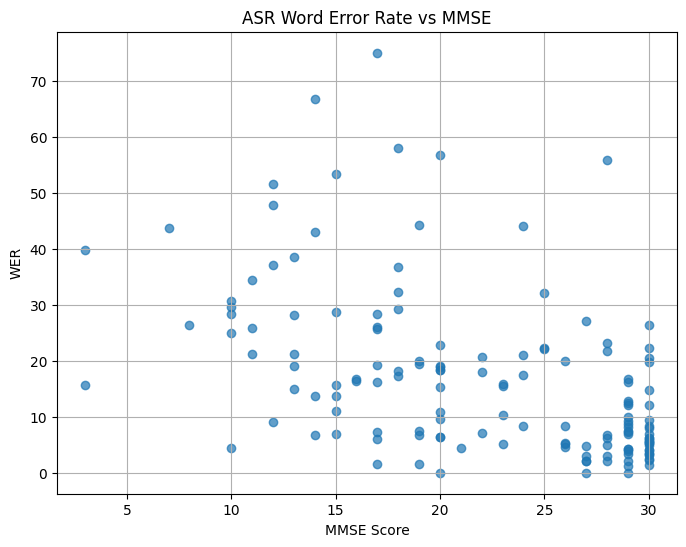

In [29]:
# Plot MMSE vs WER
plot_df = manual_check.dropna(subset=['wer', 'mmse'])

plt.figure(figsize=(8, 6))
plt.scatter(plot_df['mmse'], plot_df['wer'], alpha=0.7)
plt.xlabel('MMSE Score')
plt.ylabel('WER')
plt.title('ASR Word Error Rate vs MMSE')
plt.grid(True)
plt.show()

In [30]:
manual_check.mmse_split.value_counts()

mmse_split
ad-mod    62
cn        59
ad-mil    20
ad-sev     4
Name: count, dtype: int64

<Figure size 400x300 with 0 Axes>

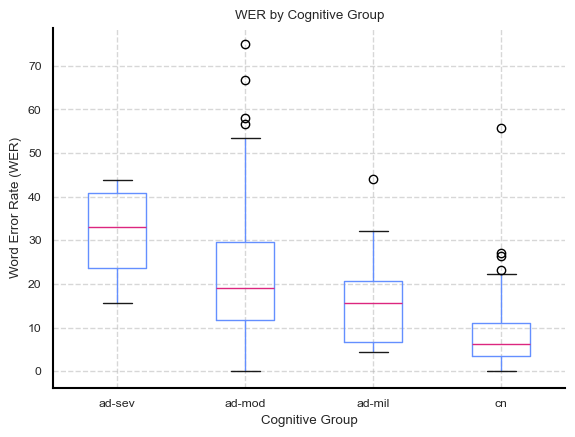

In [89]:
import matplotlib.pyplot as plt

# Drop missing WER values
plot_df = manual_check.dropna(subset=['wer', 'mmse_split'])

# Optional: enforce group order
group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']  # if this order matters
plot_df['mmse_split'] = pd.Categorical(plot_df['mmse_split'], categories=group_order, ordered=True)

with plotting.paper_theme():
    plt.close()
    # Create the boxplot
    plt.figure(figsize=(4,3))
    plot_df.boxplot(column='wer', by='mmse_split')
    plt.title("WER by Cognitive Group")
    plt.suptitle("")  # remove the automatic title from pandas
    plt.xlabel("Cognitive Group")
    plt.ylabel("Word Error Rate (WER)")
    plt.grid(True)
    plt.show()


WER intervals vs prediction WER [0-10], [10-20], [20-30], [30-40], [40, 50]

### Redo training LIWC size100 for 10-f CV results

In [2]:
df_liwc_train = pd.read_pickle('./FEATURES/dfs/liwc22-size100.pkl')
df_liwc_train

,pid,label,data
0,267,0,"[81, 58.92, 54.78, 83.36, 20.23, 4.26, 8.64, 9..."
1,273,0,"[110, 80.0, 71.57, 20.79, 47.86, 10.0, 13.64, ..."
2,298,0,"[92, 84.34, 93.93, 44.75, 35.66, 7.08, 14.13, ..."
3,307,0,"[83, 56.34, 74.41, 13.52, 76.34, 7.55, 7.23, 7..."
4,312,0,"[128, 64.33, 75.49, 48.9, 30.91, 5.82, 11.72, ..."
...,...,...,...
161,055,1,"[132, 49.68, 74.59, 55.91, 30.55, 6.6, 8.33, 9..."
162,109,1,"[154, 60.69, 92.08, 17.57, 13.3, 7.7, 13.64, 9..."
163,134,1,"[59, 94.96, 96.3, 30.14, 73.26, 6.56, 16.95, 8..."
164,054,1,"[114, 7.07, 40.06, 64.56, 46.76, 6.33, 8.77, 9..."


In [3]:
df_liwc_train.data[0].size

100

In [4]:
import os
print(os.path.isfile('./hyperparam-tuning-UPD/w-liwc-size100/10fcv_rf.pkl'))  # Should return True

True


In [8]:
with open("./hyperparam-tuning-UPD/w-liwc-size100/10fcv_rf.pkl", "rb") as f:
    print(f.read())

b'\x80\x04\x95y\x03\x00\x00\x00\x00\x00\x00\x8c\x18sklearn.ensemble._forest\x94\x8c\x16RandomForestClassifier\x94\x93\x94)\x81\x94}\x94(\x8c\testimator\x94\x8c\x15sklearn.tree._classes\x94\x8c\x16DecisionTreeClassifier\x94\x93\x94)\x81\x94}\x94(\x8c\tcriterion\x94\x8c\x04gini\x94\x8c\x08splitter\x94\x8c\x04best\x94\x8c\tmax_depth\x94N\x8c\x11min_samples_split\x94K\x02\x8c\x10min_samples_leaf\x94K\x01\x8c\x18min_weight_fraction_leaf\x94G\x00\x00\x00\x00\x00\x00\x00\x00\x8c\x0cmax_features\x94N\x8c\x0emax_leaf_nodes\x94N\x8c\x0crandom_state\x94N\x8c\x15min_impurity_decrease\x94G\x00\x00\x00\x00\x00\x00\x00\x00\x8c\x0cclass_weight\x94N\x8c\tccp_alpha\x94G\x00\x00\x00\x00\x00\x00\x00\x00\x8c\x10_sklearn_version\x94\x8c\x051.2.2\x94ub\x8c\x0cn_estimators\x94K2\x8c\x10estimator_params\x94(h\x0bh\x0fh\x10h\x11h\x12h\x13h\x14h\x16h\x15h\x18t\x94\x8c\x0ebase_estimator\x94\x8c\ndeprecated\x94\x8c\tbootstrap\x94\x88\x8c\toob_score\x94\x89\x8c\x06n_jobs\x94Nh\x15K*\x8c\x07verbose\x94K\x00\x8c\nwar

In [3]:
import joblib

train_liwc_10f = joblib.load('./hyperparam-tuning-UPD/w-liwc-size100/10fcv_rf.pkl')
train_liwc_10f

RandomForestClassifier(max_depth=16, min_samples_leaf=3, min_samples_split=4,
                       n_estimators=50, random_state=42)

In [4]:
X = df_liwc_train['data']
y = df_liwc_train['label']
X_train_2d = np.stack(X.values)
# Normalization
scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train_2d)

In [6]:
# NOTE: changed crossvalidation() to save in new folder
models = ml.create_models()
param_grids = ml.create_param_grids()

results = []
all_probas = {}

for name, model in models.items():
    output = ml.crossvalidation_with_predicted_values(name, model, param_grids[name], X_scaled_train, y, feature_set='w-liwc-size100-CHECK3')
    results.append(output['scores'])
    all_probas[name] = output['y_proba_matrix']  # Store the probabilities

df_eval_cv = pd.DataFrame(results)
df_eval_cv

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits
Fitting 10 folds for each of 50 candidates, totalling 500 fits


/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:605: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:605: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:605: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:605: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/Users/marialima/Desktop/Analysis/ml

Fitting 10 folds for each of 50 candidates, totalling 500 fits


/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:35:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:35:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:35:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/marialima/Desktop/Analysis/ml-analysis/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:35:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parame

,Model,Sensitivity,Specificity,Roc_auc,Accuracy
0,lr,70.4 (10.0),77.3 (9.2),78.6 (6.0),73.6 (6.5)
1,svm,75.0 (14.5),69.5 (14.3),78.1 (5.2),72.2 (8.6)
2,rf,78.8 (16.7),72.1 (13.4),83.5 (8.9),75.3 (9.4)
3,nn,69.4 (18.2),70.7 (17.2),73.4 (12.9),69.9 (7.9)
4,xgboost,80.6 (9.9),78.2 (16.5),85.4 (9.5),79.5 (9.6)


In [7]:
df_probs = pd.DataFrame(all_probas)
df_probs['true_label'] = y.values
df_probs.to_csv("cv_rf_predicted_probs_2.csv", index=False)

In [8]:
df_probs

,lr,svm,rf,nn,xgboost,true_label
0,0.363284,0.435093,0.414190,0.020298,0.673988,0
1,0.217627,0.220289,0.268214,0.000011,0.017274,0
2,0.363967,0.406855,0.519063,0.000659,0.264955,0
3,0.606224,0.563060,0.528136,0.999976,0.763318,0
4,0.362970,0.420181,0.302866,0.090281,0.156786,0
...,...,...,...,...,...,...
161,0.591480,0.768544,0.596000,0.999898,0.920997,1
162,0.474605,0.566251,0.554976,0.838481,0.677603,1
163,0.664842,0.472560,0.544595,0.487131,0.922067,1
164,0.703558,0.662346,0.883762,0.000008,0.891402,1


Update to have 10 runs per sample

In [10]:
name = 'rf'
models = ml.create_models()
param_grids = ml.create_param_grids()
model = models[name]

output = ml.crossvalidation_with_predicted_values(
    name, model, param_grids[name], X_scaled_train, y,
    feature_set='w-liwc-size100-CHECK3'
)

df_eval_cv = pd.DataFrame([output['scores']])

# Save predictions
probs_matrix = output['y_proba_matrix']  # shape: (n_samples, 10)
# df_probs = pd.DataFrame(probs_matrix, columns=[f'Fold_{i+1}' for i in range(10)])
df_probs = pd.DataFrame({
    'Predicted_Prob': probs_matrix,
    'True_Label': y.values
})

Fitting 10 folds for each of 50 candidates, totalling 500 fits


In [11]:
df_probs

,Predicted_Prob,True_Label
0,0.414190,0
1,0.268214,0
2,0.519063,0
3,0.528136,0
4,0.302866,0
...,...,...
161,0.596000,1
162,0.554976,1
163,0.544595,1
164,0.883762,1


In [12]:
df_probs.to_pickle('./hyperparam-tuning-UPD/w-liwc-size100-CHECK3/df_probs.pkl')

### WER per pid with 10 predictions (one per fold) 

In [13]:
df_probs = pd.read_pickle('./hyperparam-tuning-UPD/w-liwc-size100-CHECK3/df_probs.pkl')
df_probs.head()

,Predicted_Prob,True_Label
0,0.414190,0
1,0.268214,0
2,0.519063,0
3,0.528136,0
4,0.302866,0


In [14]:
df_probs['pid'] = df_liwc_train['pid'].astype(str)
df_probs.head()

,Predicted_Prob,True_Label,pid
0,0.414190,0,267
1,0.268214,0,273
2,0.519063,0,298
3,0.528136,0,307
4,0.302866,0,312


In [15]:
df_probs.pid.unique()

array(['267', '273', '298', '307', '312', '299', '266', '270', '264',
       '310', '259', '265', '261', '315', '300', '260', '274', '262',
       '276', '289', '316', '302', '277', '263', '012', '172', '167',
       '173', '007', '005', '165', '159', '158', '170', '164', '010',
       '014', '148', '160', '161', '015', '003', '017', '177', '162',
       '016', '002', '153', '152', '018', '178', '186', '151', '019',
       '021', '169', '182', '183', '154', '168', '008', '022', '156',
       '180', '157', '023', '285', '291', '292', '286', '278', '268',
       '283', '308', '309', '296', '257', '280', '281', '071', '059',
       '138', '110', '070', '072', '106', '112', '098', '249', '077',
       '063', '116', '089', '248', '060', '074', '128', '075', '049',
       '198', '211', '205', '039', '206', '212', '216', '202', '028',
       '229', '215', '188', '189', '200', '228', '027', '033', '190',
       '032', '218', '224', '232', '024', '144', '187', '192', '025',
       '031', '233',

In [16]:
df_merge = manual_check.copy()

NameError: name 'manual_check' is not defined

In [22]:
df_merge.head()

,age,gender,mmse,dx,adressfname,test,mmse_split,wer
0,70,female,26.0,Control,adrso002,False,ad-mil,5.17
1,72,female,30.0,Control,adrso003,False,cn,5.88
3,67,female,27.0,Control,adrso005,False,cn,4.86
5,62,female,30.0,Control,adrso007,False,cn,6.15
6,67,female,29.0,Control,adrso008,False,cn,2.14


In [51]:
# Step 1: Extract numeric pid from adressfname in df_merge
df_merge['pid'] = df_merge['adressfname'].str.extract(r'adrso(\d+)')

# Optional: convert to same type if needed
df_merge['pid'] = df_merge['pid'].astype(str)

df_probs['pid'] = df_probs['pid'].astype(str)
df_probs.head()

,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Fold_6,Fold_7,Fold_8,Fold_9,Fold_10,True_Label,pid
0,0.273714,0.196333,0.215857,0.414190,0.343865,0.180254,0.232753,0.216000,0.248437,0.208881,0,267
1,0.268214,0.053000,0.101310,0.087381,0.151778,0.131476,0.133667,0.081238,0.103333,0.156833,0,273
2,0.268881,0.219531,0.519063,0.308667,0.150222,0.215111,0.154460,0.281397,0.250714,0.251786,0,298
3,0.299500,0.247667,0.326333,0.528136,0.260079,0.237500,0.252619,0.164333,0.288300,0.151238,0,307
4,0.244119,0.163167,0.302866,0.218048,0.205524,0.176000,0.206333,0.210667,0.278238,0.187976,0,312


In [48]:
df_merge.head()

,age,gender,mmse,dx,adressfname,test,mmse_split,wer,pid
0,70,female,26.0,Control,adrso002,False,ad-mil,5.17,002
1,72,female,30.0,Control,adrso003,False,cn,5.88,003
3,67,female,27.0,Control,adrso005,False,cn,4.86,005
5,62,female,30.0,Control,adrso007,False,cn,6.15,007
6,67,female,29.0,Control,adrso008,False,cn,2.14,008


In [46]:
print(df_probs.columns)

Index(['Fold_1', 'Fold_2', 'Fold_3', 'Fold_4', 'Fold_5', 'Fold_6', 'Fold_7',
       'Fold_8', 'Fold_9', 'Fold_10', 'True_Label', 'PID'],
      dtype='object')


In [107]:
# Step 2: Merge df_probs with selected columns from df_merge
columns_to_add = ['age', 'gender', 'mmse', 'dx', 'mmse_split', 'wer', 'pid']
df_final = df_probs.merge(df_merge[columns_to_add], left_on='pid', right_on='pid', how='left')

# Step 3: Drop redundant merge key if needed
df_final = df_final.dropna()
df_final

,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Fold_6,Fold_7,Fold_8,Fold_9,Fold_10,True_Label,pid,age,gender,mmse,dx,mmse_split,wer
0,0.273714,0.196333,0.215857,0.414190,0.343865,0.180254,0.232753,0.216000,0.248437,0.208881,0,267,64.0,female,30.0,Control,cn,2.41
1,0.268214,0.053000,0.101310,0.087381,0.151778,0.131476,0.133667,0.081238,0.103333,0.156833,0,273,67.0,female,30.0,Control,cn,3.57
6,0.255286,0.480881,0.379190,0.252159,0.202667,0.256206,0.247111,0.206333,0.255789,0.206429,0,266,63.0,female,30.0,Control,cn,5.49
7,0.196905,0.170333,0.184167,0.179667,0.069000,0.106683,0.078333,0.162111,0.304040,0.162333,0,270,61.0,female,30.0,Control,cn,12.17
8,0.447349,0.262333,0.218238,0.226111,0.247873,0.277071,0.169921,0.146635,0.207833,0.223008,0,264,73.0,male,29.0,Control,cn,12.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,0.739262,0.718722,0.745580,0.846333,0.596000,0.718635,0.691381,0.735659,0.766249,0.734444,1,055,65.0,female,17.0,ProbableAD,ad-mod,16.22
162,0.765944,0.554976,0.843286,0.716167,0.775810,0.746262,0.772143,0.758175,0.671611,0.690392,1,109,70.0,female,20.0,ProbableAD,ad-mod,19.09
163,0.648690,0.785778,0.781722,0.544595,0.780619,0.824389,0.718532,0.733849,0.714405,0.717286,1,134,79.0,female,8.0,ProbableAD,ad-sev,26.32
164,0.894111,0.903667,0.892667,0.911333,0.883762,0.951587,0.893452,0.939778,0.946667,0.959143,1,054,60.0,female,12.0,ProbableAD,ad-mod,47.83


Wihout considering each fold as a different data sample

In [108]:
# Step 1: Compute mean predicted probability across folds
fold_cols = [f'Fold_{i+1}' for i in range(10)]
df_final['mean_pred'] = df_final[fold_cols].mean(axis=1)

# Step 2: Convert mean prediction to binary label
df_final['mean_pred_label'] = (df_final['mean_pred'] >= 0.5).astype(int)

# Step 3: Compare to true label
df_final['correct'] = (df_final['mean_pred_label'] == df_final['True_Label']).astype(int)

# Step 4: Bin by WER
bins = [0, 10, 20, 30, 40, 100]
labels = ['[0-10]', '[10-20]', '[20-30]', '[30-40]', '[40-100]']
df_final['wer_bin'] = pd.cut(df_final['wer'], bins=bins, labels=labels, right=False)

# Step 5: Compute accuracy per bin
accuracy_by_bin = df_final.groupby('wer_bin')['correct'].mean().reset_index()
accuracy_by_bin.rename(columns={'correct': 'Accuracy'}, inplace=True)


/var/folders/lm/sz7z6d6x725_9nyqv0hzt1jm0000gn/T/ipykernel_22134/732390646.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_by_bin = df_final.groupby('wer_bin')['correct'].mean().reset_index()


In [67]:
accuracy_by_bin

,wer_bin,Accuracy
0,[0-10],1.0
1,[10-20],1.0
2,[20-30],1.0
3,[30-40],1.0
4,[40-100],1.0


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define WER bins
bins = [0, 10, 20, 30, 100]
labels = ['[0-10]', '[10-20]', '[20-30]', '[30-100]']
df_final['wer_bin'] = pd.cut(df_final['wer'], bins=bins, labels=labels, right=False)

# Step 2: Collect accuracy per fold per bin
records = []

for fold in range(10):
    fold_col = f'Fold_{fold + 1}'
    preds = (df_final[fold_col] >= 0.5).astype(int)  # binary predictions
    true = df_final['True_Label']

    for bin_label in labels:
        bin_mask = df_final['wer_bin'] == bin_label
        if bin_mask.sum() > 0:
            acc = (preds[bin_mask].values == true[bin_mask].values).mean()
            records.append({
                'Fold': fold + 1,
                'WER Bin': bin_label,
                'Accuracy': acc
            })

df_acc_by_bin = pd.DataFrame(records)


In [60]:
df_acc_by_bin

,Fold,WER Bin,Accuracy
0,1,[0-10],0.984615
1,1,[10-20],1.000000
2,1,[20-30],0.960000
3,1,[30-100],0.950000
4,2,[0-10],0.984615
5,2,[10-20],0.971429
6,2,[20-30],1.000000
7,2,[30-100],0.950000
8,3,[0-10],1.000000
9,3,[10-20],1.000000


In [110]:
# Get only the 10 fold prediction columns
fold_cols = [f'Fold_{i+1}' for i in range(10)]
pred_matrix = df_final[fold_cols].values >= 0.5  # shape: (n_samples, 10)
true_labels = df_final['True_Label'].values.reshape(-1, 1)  # shape: (n_samples, 1)

# Compare each fold's prediction with true label: gives a (n_samples, 10) boolean matrix
correct_matrix = (pred_matrix == true_labels).astype(int)

# Compute per-sample accuracy across folds
df_final['sample_accuracy'] = correct_matrix.mean(axis=1)

bins = [0, 10, 20, 30, 100]
labels = ['[0-10]', '[10-20]', '[20-30]', '[30-100]']
df_final['wer_bin'] = pd.cut(df_final['wer'], bins=bins, labels=labels, right=False)

df_final

,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Fold_6,Fold_7,Fold_8,Fold_9,Fold_10,...,gender,mmse,dx,mmse_split,wer,mean_pred,mean_pred_label,correct,wer_bin,sample_accuracy
0,0.273714,0.196333,0.215857,0.414190,0.343865,0.180254,0.232753,0.216000,0.248437,0.208881,...,female,30.0,Control,cn,2.41,0.253028,0,1,[0-10],1.0
1,0.268214,0.053000,0.101310,0.087381,0.151778,0.131476,0.133667,0.081238,0.103333,0.156833,...,female,30.0,Control,cn,3.57,0.126823,0,1,[0-10],1.0
6,0.255286,0.480881,0.379190,0.252159,0.202667,0.256206,0.247111,0.206333,0.255789,0.206429,...,female,30.0,Control,cn,5.49,0.274205,0,1,[0-10],1.0
7,0.196905,0.170333,0.184167,0.179667,0.069000,0.106683,0.078333,0.162111,0.304040,0.162333,...,female,30.0,Control,cn,12.17,0.161357,0,1,[10-20],1.0
8,0.447349,0.262333,0.218238,0.226111,0.247873,0.277071,0.169921,0.146635,0.207833,0.223008,...,male,29.0,Control,cn,12.37,0.242637,0,1,[10-20],1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,0.739262,0.718722,0.745580,0.846333,0.596000,0.718635,0.691381,0.735659,0.766249,0.734444,...,female,17.0,ProbableAD,ad-mod,16.22,0.729227,1,1,[10-20],1.0
162,0.765944,0.554976,0.843286,0.716167,0.775810,0.746262,0.772143,0.758175,0.671611,0.690392,...,female,20.0,ProbableAD,ad-mod,19.09,0.729477,1,1,[10-20],1.0
163,0.648690,0.785778,0.781722,0.544595,0.780619,0.824389,0.718532,0.733849,0.714405,0.717286,...,female,8.0,ProbableAD,ad-sev,26.32,0.724987,1,1,[20-30],1.0
164,0.894111,0.903667,0.892667,0.911333,0.883762,0.951587,0.893452,0.939778,0.946667,0.959143,...,female,12.0,ProbableAD,ad-mod,47.83,0.917617,1,1,[30-100],1.0


In [111]:
# Step 1: Select fold columns
fold_cols = [f'Fold_{i+1}' for i in range(10)]

# Step 2: Calculate mean and standard deviation across folds
df_final['mean_pred'] = df_final[fold_cols].mean(axis=1)
df_final['std_pred'] = df_final[fold_cols].std(axis=1)

# Step 3: Group by cognitive group (mmse_split) and calculate mean and std
group_stats = df_final.groupby('mmse_split').agg(
    mean_predicted_probability=('mean_pred', 'mean'),
    std_predicted_probability=('mean_pred', 'std')
).reset_index()

# Display the results
group_stats

,mmse_split,mean_predicted_probability,std_predicted_probability
0,ad-mil,0.648795,0.185470
1,ad-mod,0.781114,0.108223
2,ad-sev,0.843497,0.098738
3,cn,0.265436,0.125886


### Plot with 2 data types: WER, performance on the validation set 

In [120]:
df_plot = df_final.copy()

In [114]:
print(df_plot['mmse_split'].unique())

['cn' 'ad-mil' 'ad-mod' 'ad-sev']


In [115]:
import matplotlib.pyplot as plt

# Step 1: Compute required group stats
group_stats = df_plot.groupby('mmse_split').agg(
    mean_pred=('mean_pred', 'mean'),
    std_pred=('mean_pred', 'std'),
    mean_wer=('wer', 'mean'),
    count=('pid', 'count')  # Optional, if needed
).reindex(['ad-sev', 'ad-mod', 'ad-mil', 'cn'])  # ensure group order
group_stats


,mean_pred,std_pred,mean_wer,count
mmse_split,,,,
ad-sev,0.843497,0.098738,31.395000,4
ad-mod,0.781114,0.108223,23.525323,62
ad-mil,0.648795,0.185470,15.379000,20
cn,0.265436,0.125886,8.939153,59


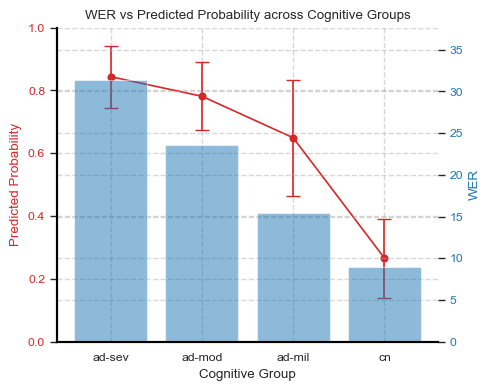

In [116]:
# Step 2: Prepare values
groups = group_stats.index.tolist()
mean_pred = group_stats['mean_pred'].values
std_pred = group_stats['std_pred'].values
mean_wer = group_stats['mean_wer'].values

with plotting.paper_theme():
    plt.close()
    # Step 3: Plot
    fig, ax1 = plt.subplots(figsize=(5,4))

    # Right axis: WER bar plot
    ax2 = ax1.twinx()
    ax2.bar(groups, mean_wer, alpha=0.5, color='tab:blue', label='Mean WER')
    ax2.set_ylabel('WER', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(0, max(mean_wer)*1.2)

    # Left axis: Model performance (predicted probability)
    ax1.errorbar(groups, mean_pred, yerr=std_pred, fmt='o-', color='tab:red',
                ecolor='tab:red', capsize=5, label='Predicted Probability')
    ax1.set_ylabel('Predicted Probability', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_ylim(0, 1)

    # Styling
    ax1.set_title('WER vs Predicted Probability across Cognitive Groups')
    ax1.set_xlabel('Cognitive Group')
    fig.tight_layout()
    plt.grid(True, axis='y')
    plt.show()


In [121]:
df_plot.head()

,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Fold_6,Fold_7,Fold_8,Fold_9,Fold_10,...,mmse,dx,mmse_split,wer,mean_pred,mean_pred_label,correct,wer_bin,sample_accuracy,std_pred
0,0.273714,0.196333,0.215857,0.414190,0.343865,0.180254,0.232753,0.216000,0.248437,0.208881,...,30.0,Control,cn,2.41,0.253028,0,1,[0-10],1.0,0.073255
1,0.268214,0.053000,0.101310,0.087381,0.151778,0.131476,0.133667,0.081238,0.103333,0.156833,...,30.0,Control,cn,3.57,0.126823,0,1,[0-10],1.0,0.059507
6,0.255286,0.480881,0.379190,0.252159,0.202667,0.256206,0.247111,0.206333,0.255789,0.206429,...,30.0,Control,cn,5.49,0.274205,0,1,[0-10],1.0,0.088378
7,0.196905,0.170333,0.184167,0.179667,0.069000,0.106683,0.078333,0.162111,0.304040,0.162333,...,30.0,Control,cn,12.17,0.161357,0,1,[10-20],1.0,0.067472
8,0.447349,0.262333,0.218238,0.226111,0.247873,0.277071,0.169921,0.146635,0.207833,0.223008,...,29.0,Control,cn,12.37,0.242637,0,1,[10-20],1.0,0.081974


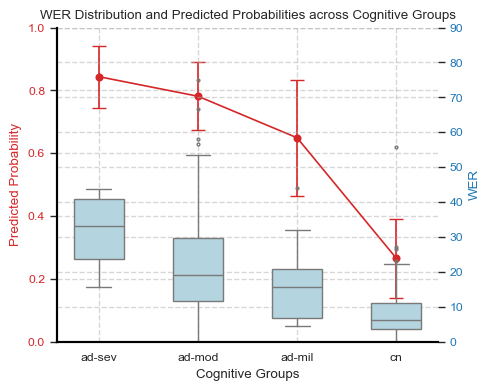

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Ensure proper group order and formatting
# Replace values in mmse_split


group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']
df_plot['mmse_split'] = df_plot['mmse_split'].astype(str).str.strip()

# Step 2: Grouped statistics for predicted probability
group_stats = df_plot.groupby('mmse_split').agg(
    mean_pred=('mean_pred', 'mean'),
    std_pred=('mean_pred', 'std')
).reindex(group_order)

# Extract values
groups = group_stats.index.tolist()
mean_preds = group_stats['mean_pred'].values
std_preds = group_stats['std_pred'].values

with plotting.paper_theme():
    plt.close()
    # Step 3: Set up plot
    fig, ax1 = plt.subplots(figsize=(5, 4))

    # Right Y-axis: WER boxplot
    ax2 = ax1.twinx()
    sns.boxplot(data=df_plot, x='mmse_split', y='wer', order=group_order,
                ax=ax2, color='lightblue', width=0.5, fliersize=2)
    ax2.set_ylabel('WER', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(0, df_plot['wer'].max() * 1.2)

    # Left Y-axis: Predicted probs with std error lines
    ax1.errorbar(groups, mean_preds, yerr=std_preds, fmt='o-', color='tab:red',
                ecolor='tab:red', capsize=5, label='Predicted Probabilities')
    ax1.set_ylabel('Predicted Probability', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    ax1.set_ylim(0, 1)

    # X-axis styling
    ax1.set_xlabel('Cognitive Groups')
    ax1.set_title('WER Distribution and Predicted Probabilities across Cognitive Groups')
    ax1.grid(True, axis='y')
    fig.tight_layout()

    plt.show()


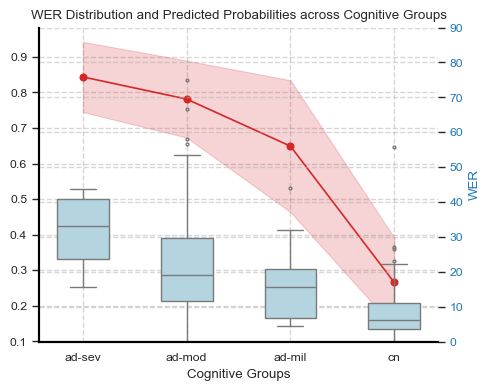

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Ensure proper group order and formatting
# Replace values in mmse_split


group_order = ['ad-sev', 'ad-mod', 'ad-mil', 'cn']
df_plot['mmse_split'] = df_plot['mmse_split'].astype(str).str.strip()

# Step 2: Grouped statistics for predicted probability
group_stats = df_plot.groupby('mmse_split').agg(
    mean_pred=('mean_pred', 'mean'),
    std_pred=('mean_pred', 'std')
).reindex(group_order)

# Extract values
groups = group_stats.index.tolist()
mean_preds = group_stats['mean_pred'].values
std_preds = group_stats['std_pred'].values

with plotting.paper_theme():
    plt.close()
    # Step 3: Set up plot
    fig, ax1 = plt.subplots(figsize=(5, 4))

    # Right Y-axis: WER boxplot
    ax2 = ax1.twinx()
    sns.boxplot(data=df_plot, x='mmse_split', y='wer', order=group_order,
                ax=ax2, color='lightblue', width=0.5, fliersize=2)
    ax2.set_ylabel('WER', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(0, df_plot['wer'].max() * 1.2)

    # Numeric x positions for plotting
    x_pos = np.arange(len(groups))

    # Plot shaded line (mean ± std)
    ax1.plot(x_pos, mean_preds, marker='o', color='tab:red', label='Mean Prediction')
    ax1.fill_between(x_pos, mean_preds - std_preds, mean_preds + std_preds, 
                    alpha=0.2, color='tab:red', label='±1 std')

    # Set x-tick positions and labels
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(groups)

    # X-axis styling
    ax1.set_xlabel('Cognitive Groups')
    ax1.set_title('WER Distribution and Predicted Probabilities across Cognitive Groups')
    ax1.grid(True, axis='y')
    fig.tight_layout()

    plt.show()
